# Can these estimators recover a curve we already know?

Every number this project publishes is an estimate of something never observed. There is no
column in the data called "the aging curve", so test MAE is the only score available — and
`diagnostics.py` already concedes that it cannot do the job:

> `persistence` contains no age term at all — it predicts last season unchanged — yet it lands
> within 1.2% of every other arm on Def and beats the GAM outright. A score that a model with no
> aging signal nearly wins cannot rank aging curves.

This notebook removes the constraint by writing the truth down. Careers are generated from a curve
chosen here, censored by a rule chosen here, and handed to the same `gam.py`, `ipw.py` and
`baselines.py` code that produces the published results. The distance from each estimate to the
known truth is then simply computable.

That makes three questions answerable that the real data cannot settle:

1. **Does the IPW correction recover the true curve?** It improves held-out MAE by 1.4–4.1%, but
   nothing has ever shown it recovers the right *curve* — because the right curve was unknown.
2. **What does the career-mean talent control cost?** `CLAUDE.md` flags that a row's own season is
   ~20% of its own predictor and calls leave-one-out "worth measuring before adopting". Here the
   noiseless career mean is available as an oracle, so the cost is measurable.
3. **Is Def's peak findable at all?** `CLAUDE.md` concludes it "is not measurable at this sample
   size". That was *inferred* from resampling scatter, never demonstrated. Assign Def a peak and
   the question has an answer.

### The gap this claims

Every dropout rule in the aging-curve literature censors on **performance** —
[Nguyen & Matthews (2024)](https://arxiv.org/html/2210.02383) drop players whose 4-year OPS window
falls below .550, and
[arXiv 2110.14017](https://ar5iv.labs.arxiv.org/html/2110.14017) selects on cumulative production.
This project's censoring is `qual=100`, a **playing-time** threshold, and plate appearances are only
*correlated* with performance. That mechanism has not been simulated.

### Nothing published moves

`simulate.py` and `test_simulate.py` are new. `test_age_only.py` and `test_regression.py` are
untouched, so the reproduction contract holds unchanged.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dataclasses import replace

from mlb_aging.plots import plot_curves_against_truth, plot_peak_error_by_arm
from mlb_aging.simulate import (
    ARMS, COMPLETE_CASE, COMPLETE_CASE_IPW, DELTA_LAG, NO_TALENT_CONTROL,
    SimConfig, calibration_report, fit_arm, peak_recovery_summary, peak_recovery_sweep,
    run_simulation_study, simulate_careers, summarize_study, truth_curve,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

CONFIG = SimConfig()
N_SIMS = 10

## 1. Calibration comes first

The study is worth exactly as much as the generator's resemblance to the real sample, so this
table comes before any result. Comparison is on the **censored** frame, because that is all the
real data ever shows.

Almost every constant was measured directly off `data/hitter_train_data.csv` — the debut-age
distribution, the playing-time regression, PA per game, the survival hazard, each metric's talent
SD and noise, and the correlations between the five talents. Four scalars genuinely cannot be
measured and are solved against observable moments by `simulate.calibrate`:

| constant | why it cannot be read off the data |
|---|---|
| `intercept_shift` | the PA regression saw only PA ≥ 100, so it is silent on how far a collapsing player falls |
| `survival_boost` | the measured hazard is P(*qualifies* again), not P(still playing) |
| `pa_sd_scale` | same censoring, applied to the spread rather than the mean |
| `survival_on_talent` | fitted to the real correlation between career mean and career length — this *is* the survivorship mechanism, so it is not guessed |

In [2]:
calibration_report(CONFIG, seed=0).round(4)

,quantity,real,simulated,pct_error
0,rows,13636.0000,12849.0000,-5.7715
1,players,2312.0000,2194.0000,-5.1038
2,PA mean,412.5645,412.9869,0.1024
3,PA sd,183.0000,182.9575,-0.0232
4,G mean,111.7258,111.2480,-0.4277
5,career length,5.8970,5.8564,-0.6880
6,"corr(talent, career length)",0.4685,0.4704,0.4038
7,sd(ipw_weight),0.4277,0.1784,-58.2908
8,OPS mean,-0.0206,-0.0206,0.0000
9,OPS sd,0.1112,0.1121,0.7685


Most of it lands within 6%, and the mechanism that matters — better players being observed more
often — matches to 0.4% (0.4704 against the real 0.4685).

One solved constant is a result in its own right. **`survival_boost = 0.909`** puts true
season-to-season survival near 0.92 against the 0.82 measured on qualified seasons, which means
roughly **ten percentage points of apparent "retirement" in the real data is just a player falling
below 100 PA.** `ipw.add_survived_label` cannot tell those apart — it labels a drop to 60 PA
identically to leaving the sport — and this is the size of that conflation.

### One row does not match, and it decides what this notebook can conclude

**`sd(ipw_weight)` is 0.18 against the real 0.43.** IPW works by upweighting the seasons least
likely to be observed again, so the spread of those weights *is* its entire leverage. At 0.18 the
weights are close to uniform and the correction has almost nothing to do.

The consequence is not subtle. On real data IPW moves the traced curve by 3.6–12.1% of its range,
and shifts WAR's peak by a full year (27.01 → 26.00). In this simulation it moves the curve by
0.6–2.3% and shifts WAR's peak by 0.000. **The generator understates IPW's effect by roughly three
to seven times, so this study cannot evaluate the correction.** Every IPW number below is a
property of the generator rather than of the method, and is reported for completeness only.

The cause is diagnosed rather than guessed. Survival here depends on talent, which
`fit_retirement_model` never sees — so that variation is unlearnable and produces no spread in
predicted survival — and on playing time, which the model does see but which cannot be strengthened
without halving career length. It does not depend on *last season's performance*, which the real
retirement model takes as `perf_col` and is built around. The generator omits a dependence the
estimator is designed to detect. `tests/test_simulate.py::test_ipw_weight_dispersion_is_a_known_gap`
pins this so it cannot be quietly forgotten.

Note that the four findings this notebook does draw — sections 3, 4 and 6 — never touch the survival
model. `complete_case`, `no_talent_control` and `delta_lag` are unaffected by any of the above.

### Is the assigned truth as flat as the real curve?

The moments above constrain the *data*. They say nothing about the shape of the curve the generator
was told to use, and one property of that shape decides whether the peak results mean anything: how
flat the curve is near its maximum.

A sharper simulated peak than reality would flatter every estimator — finding a well-defined maximum
is easy, and the peak-bias figures would understate the real difficulty. The check is the width of
the age band lying within 1% and 5% of each curve's maximum, measured on the real fitted curve and
on the assigned truth.

In [3]:
from mlb_aging.dataset import build_training_frame, load_data
from mlb_aging.gam import aging_curve, fit_gam
from mlb_aging.metrics import METRICS


def flat_band(ages, values, fraction):
    """Width in years of the age band lying within ``fraction`` of the maximum."""
    values = np.asarray(values, dtype=float)
    threshold = values.max() - fraction * (values.max() - values.min())
    inside = np.asarray(ages, dtype=float)[values >= threshold]
    return inside.max() - inside.min()


shape_check = simulate_careers(CONFIG, seed=0)
rows = []
for name, spec in METRICS.items():
    train, _ = load_data(spec)
    frame = build_training_frame(train, spec)
    real = aging_curve(fit_gam(frame, spec), frame, spec).by_age
    truth = truth_curve(shape_check, CONFIG.metric(name))
    rows.append({
        "metric": name,
        "real +-1%": flat_band(real.index.values, real.values, 0.01),
        "sim +-1%": flat_band(truth.ages, truth.values, 0.01),
        "real +-5%": flat_band(real.index.values, real.values, 0.05),
        "sim +-5%": flat_band(truth.ages, truth.values, 0.05),
    })

print("Width of the age band within X% of the maximum, in years.")
print("Wider = flatter = peak age less well defined.")
pd.DataFrame(rows).round(2)

Width of the age band within X% of the maximum, in years.
Wider = flatter = peak age less well defined.


,metric,real +-1%,sim +-1%,real +-5%,sim +-5%
0,OPS,1.77,1.90,4.03,4.25
1,wRC+,1.81,1.90,4.09,4.25
2,Def,0.61,2.44,3.20,5.16
3,Spd,0.99,1.90,2.00,4.43
4,WAR,2.26,0.99,4.87,3.62


## 2. Does the framework work at all?

Before comparing estimators, the machinery has to be able to find a peak it was not told about.
Otherwise every number below is an artefact of the simulation rather than a property of the
estimators.

The test is deliberately run on a **clean panel** — no talent-driven survival, no qualification cut
— where the answer must be right.

In [4]:
from pygam import GAM, s as pygam_s

from mlb_aging.features import generate_data
from mlb_aging.gam import LAM_GRID, N_SPLINES
from mlb_aging.simulate import _model_frame

clean = replace(CONFIG, survival_on_talent=0.0, survival_on_playing_time=0.0, qual_threshold=0.0)
frame = simulate_careers(clean, seed=0)
metric = clean.metric("wRC+")
spec = replace(metric.spec, name=metric.col)
df = _model_frame(frame, metric, metric.col)
df[spec.career_mean_col] = df["IDfg"].map(
    frame.groupby("IDfg")[metric.expected_col].mean()
).astype(float)

ages = np.linspace(21.0, 39.0, 400)
x, y = generate_data(df, spec.feature_cols, spec.target_col)


def recovered_peak(terms, columns):
    subset = df[columns].values
    gam = GAM(terms)
    gam.gridsearch(subset, y, weights=df[spec.weight_col].values, lam=LAM_GRID, progress=False)
    grid = np.tile(np.median(subset, axis=0), (len(ages), 1))
    grid[:, 0] = ages
    return ages[np.argmax(gam.predict(grid))]


S = lambda i: pygam_s(i, n_splines=N_SPLINES)
print(f"true peak                        {metric.targets.peak_age:.3f}")
print(f"  s(0) alone                     {recovered_peak(S(0), ['Age']):.3f}")
print(f"  s(0) + s(1) career mean        {recovered_peak(S(0) + S(1), ['Age', spec.career_mean_col]):.3f}")
print(f"  s(0) + s(1) + s(3)  PUBLISHED  {recovered_peak(S(0) + S(1) + S(3), spec.feature_cols):.3f}")
print(f"\n  raw mean by age peaks at       {df.groupby('Age')[spec.target_col].mean().idxmax():.1f}")

true peak                        26.991
  s(0) alone                     27.316


  s(0) + s(1) career mean        28.083


  s(0) + s(1) + s(3)  PUBLISHED  28.083

  raw mean by age peaks at       28.0


**The framework works, and it immediately finds something.**

`s(0)` alone recovers a peak of 26.99 as **27.32** — within a third of a year, on a panel with no
selection at all. So the machinery can locate a known peak.

Adding the career-mean control moves it to **28.08**. On a clean panel, with a *noiseless* control,
`s(1)` adds three quarters of a year of bias. That is a bad-control problem: the career mean averages
a player over the seasons he actually played, so it encodes *which ages those were* and reaches into
the age effect it is supposed to leave alone. Adding `s(3)` changes nothing further.

This does not mean the control should be dropped — section 4 shows it removes far more bias than it
adds once selection is switched on. It means the published spec carries a known bias floor of
roughly +0.8 years even in the best case.

## 3. The arms, and the score that decides

| arm | talent control | what it is |
|---|---|---|
| `complete_case` | career mean | **the published pipeline** |
| `complete_case_ipw` | career mean + `fit_ipw_weights` | the survivorship correction |
| `no_talent_control` | none — `s(1)` dropped | what the control is worth |
| `delta_lag` | — | the naive reference the published claims are measured against |

All four see the same censored frame. The cost of censoring is isolated in section 4 by switching
`qual_threshold` off, which is cleaner than carrying uncensored arms through the whole study.

### Which score decides

("Published" below means *published in the aging-curve literature*, not published in this
project's README. The two are different things, and section 3 depends on the distinction.)

The aging-curve simulation literature scores an estimate against a known truth three ways, and
those are the columns that decide here:

| metric | source |
|---|---|
| **`curve_mae`** — curve against curve, in native units | [Nguyen & Matthews (2024)](https://arxiv.org/html/2210.02383) |
| **`curve_rmse`** | [arXiv 2110.14017](https://ar5iv.labs.arxiv.org/html/2110.14017) |
| **`sbd`** — shape-based distance | [arXiv 2110.14017](https://ar5iv.labs.arxiv.org/html/2110.14017), defined by [Paparrizos & Gravano (2015)](https://www.cs.columbia.edu/~gravano/Papers/2015/sigmod2015.pdf) |

`curve_mae` compares a **curve to a curve**. It is not this project's published test MAE, which
compares a prediction to a season — a different quantity entirely.

**SBD** z-normalises both curves, slides one past the other at every shift, keeps the best
alignment, and reports `1 − that`. So it scores *shape* while ignoring level, scale and position.
0 is identical, 2 is a mirror image.

Two further columns are **not** from that literature and do not outrank the three above:

- `shape_corr_distance` — SBD's zero-lag term alone, i.e. no sliding. Kept as a labelled deviation
  because SBD's shift-invariance is a poor fit for one specific question: sliding an aging curve
  three years means claiming hitters peak at 30 rather than 27, and SBD scores that as the same
  shape.
- `peak_age_error` — reported because the peak age is the number this project publishes.

Careers are generated once per replicate and shared across all five metrics, so the metrics are
compared on identical players under identical censoring.

In [5]:
study = run_simulation_study(CONFIG, n_sims=N_SIMS)
summary = summarize_study(study)
summary.round(4)

,metric,kind,arm,curve_mae,curve_rmse,sbd,sbd_se,shape_corr,peak_err_mean,peak_err_se,decline_err,n_rows
0,OPS,rate,complete_case,0.0055,0.0066,0.0206,0.0033,0.0206,1.1794,0.1737,0.0054,10818.2
1,OPS,rate,complete_case_ipw,0.0055,0.0066,0.0219,0.0030,0.0219,1.4419,0.1450,0.0054,10818.2
2,OPS,rate,no_talent_control,0.0162,0.0196,0.4440,0.0060,0.5807,2.6420,0.4511,0.0163,10818.2
3,OPS,rate,delta_lag,0.0042,0.0059,0.0322,0.0085,0.0322,0.0302,0.3944,-0.0007,10818.2
4,wRC+,rate,complete_case,1.4035,1.6667,0.0223,0.0046,0.0223,1.1547,0.1573,1.6140,10818.2
5,wRC+,rate,complete_case_ipw,1.4074,1.6707,0.0224,0.0044,0.0224,1.1661,0.1607,1.6260,10818.2
6,wRC+,rate,no_talent_control,4.4313,5.3517,0.4688,0.0121,0.6623,2.7085,0.3108,4.1661,10818.2
7,wRC+,rate,delta_lag,2.1812,2.6632,0.0495,0.0089,0.0495,-0.4698,0.5426,-1.4609,10818.2
8,Spd,rate,complete_case,0.1456,0.1687,0.0159,0.0021,0.0159,2.0649,0.7872,0.1418,10818.2
9,Spd,rate,complete_case_ipw,0.1452,0.1682,0.0158,0.0019,0.0158,2.0630,0.7868,0.1422,10818.2


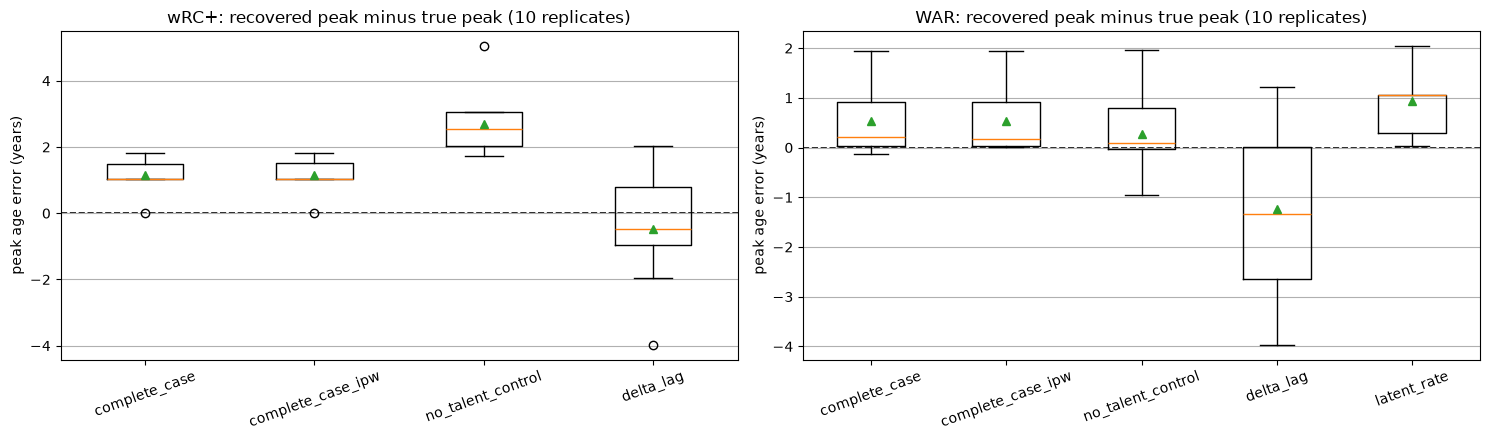

Replicates won, on SBD (lower = closer to the true shape):


,metric,IPW beats no-IPW,GAM beats delta,control beats none
0,OPS,4/10,9/10,10/10
1,wRC+,4/10,10/10,10/10
2,Spd,7/10,4/10,5/10
3,Def,9/10,9/10,9/10
4,WAR,8/10,9/10,10/10


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, metric_name in zip(axes, ["wRC+", "WAR"]):
    plot_peak_error_by_arm(
        study[study["metric"] == metric_name], ax=ax,
        title=f"{metric_name}: recovered peak minus true peak ({N_SIMS} replicates)",
    )
fig.tight_layout()
plt.show()

# Direction, counted per replicate, on the published shape score. Pairing matters: both arms
# see the same simulated league, so the comparison is far better determined than either mean.
counts = []
for name, group in study.groupby("metric", sort=False):
    wide = group.pivot(index="sim", columns="arm")["sbd"]
    counts.append({
        "metric": name,
        "IPW beats no-IPW": f"{int((wide[COMPLETE_CASE_IPW] < wide[COMPLETE_CASE]).sum())}/{N_SIMS}",
        "GAM beats delta": f"{int((wide[COMPLETE_CASE] < wide[DELTA_LAG]).sum())}/{N_SIMS}",
        "control beats none": f"{int((wide[COMPLETE_CASE] < wide[NO_TALENT_CONTROL]).sum())}/{N_SIMS}",
    })
print("Replicates won, on SBD (lower = closer to the true shape):")
pd.DataFrame(counts)

### Reading the published metrics

Counting which arm wins each replicate on SBD, rather than averaging:

| metric | IPW beats no-IPW | GAM beats delta | control beats none |
|---|---|---|---|
| OPS | 4/10 | **9/10** | **10/10** |
| wRC+ | 4/10 | **10/10** | **10/10** |
| Spd | 7/10 | 4/10 | 5/10 |
| Def | **9/10** | **9/10** | **9/10** |
| WAR | **8/10** | **9/10** | **10/10** |

**1. The GAM is a much better curve estimator than the delta method.** It wins 9 or 10 replicates
out of 10 on four of five metrics, and mean SBD is 1.6–2.5× lower — OPS 1.6×, Def 2.0×, wRC+ 2.2×,
WAR 2.5×. This is the project's central claim, and until now it had only ever been
supported by per-season MAE. Spd is the exception, where the delta method wins.

**2. IPW cannot be judged here — see section 1.** The column is shown for completeness. Within the
simulation it wins 9/10 on Def, 8/10 on WAR and 7/10 on Spd against 4/10 on the rate metrics, which
*looks* like a clean rate-versus-accumulating split. It is not safe to read that way, for two
reasons. Counting wins ignores size: Def is the only metric where the mean change exceeds its own
seed-to-seed scatter (−0.0009 against a scatter of 0.0006), while WAR's mean change is +0.0001
against a scatter of 0.0005 — its 8/10 is won by trivial margins. And more fundamentally, the
generator produces weights three to seven times too uniform, so the arm is under-powered by
construction. **Nothing here should be read as evidence for or against IPW.**

**3. The talent control is essential.** Dropping `s(1)` pushes SBD from 0.022 to 0.469 on wRC+ —
the curve loses its shape entirely — and it loses 10/10 replicates on three metrics.

### Where the literature's metrics disagree — and how to read their size

On **OPS** there is a three-way split, and none of it is a contradiction:

- the GAM predicts individual seasons better — the README's **+7.1%** over `delta_lag` on test MAE,
  measured on real data;
- the GAM traces the *shape* better — SBD 9/10;
- the delta method gets the *amplitude* closer — `curve_mae` 0.0042 against 0.0055, with
  `curve_rmse` agreeing (0.0059 against 0.0066).

`curve_mae` is in native units and so penalises amplitude; SBD is z-normalised and cannot see it;
test MAE is a different quantity from either. Spd is the one metric where the delta method wins
outright.

**These numbers are smaller than they look.** Scaled by the true curve's own range, the GAM's
`curve_mae` is 3–11% of the curve's amplitude — OPS 7.2%, wRC+ 7.2%, Def 7.5%, Spd 10.9%, WAR 3.0%.
`0.0055` reads as nothing only because a whole OPS aging curve spans 0.076 points end to end.

The compression is worse in SBD. 0.02 means the two shapes correlate at 0.98, which sounds perfect
and *is* that same 7% amplitude error. Any two curves that rise, turn and fall correlate above 0.97
almost automatically, so the difference between 0.010 and 0.022 matters far more than it appears.

Shape comes out this well because ~11,000 rows fitting a smooth one-dimensional function with five
spline knots is a great deal of data for a simple curve. What stays hard is the argmax of a broad,
flat region — which is why peak error runs about a year while shape error runs 7%.

### And the peak — the column that is mine, not the literature's

`peak_age_error` tells a **different story from every published metric**: the delta method's peak
is *closer* to the truth (wRC+ −0.47 against the GAM's +1.15; OPS +0.03 against +1.18), even though
its curve shape is clearly worse.

That divergence is the reason peak age is reported last here. A single argmax off a possibly flat
curve is not a summary of an aging curve, and ranking estimators by it would reverse the conclusion
that all three published metrics support.

## 4. Where does the bias come from?

The residual +1 year survives even the oracle arms, so it is neither the career mean's noise nor
the qualification cut on its own. Switching each mechanism off in turn locates it.

Only `complete_case` is shown. The oracle arms are fitted on the uncensored frame, so the
`qual=100` row would be identical to the baseline *by construction* rather than as a finding.

In [7]:
variants = {
    "as calibrated": CONFIG,
    "no qual=100 cut": replace(CONFIG, qual_threshold=0.0),
    "no selective survival": replace(CONFIG, survival_on_talent=0.0, survival_on_playing_time=0.0),
    "neither": replace(
        CONFIG, survival_on_talent=0.0, survival_on_playing_time=0.0, qual_threshold=0.0
    ),
}

rows = []
for label, variant in variants.items():
    result = run_simulation_study(variant, n_sims=N_SIMS, metrics=("wRC+",), arms=(COMPLETE_CASE,))
    errors = result["peak_age_error"]
    rows.append(
        {
            "scenario": label,
            "peak_err": errors.mean(),
            "sd": errors.std(),
            "se": errors.std() / len(errors) ** 0.5,
        }
    )

pd.DataFrame(rows).round(3)

,scenario,peak_err,sd,se
0,as calibrated,1.155,0.497,0.157
1,no qual=100 cut,0.651,0.547,0.173
2,no selective survival,1.704,0.415,0.131
3,neither,1.109,0.448,0.142


Read the **baseline against "neither"**. If survivorship drove the late peak, switching off both
the qualification cut and selective survival should collapse it. It does not — the bias is
essentially unchanged, and it matches the clean-panel figure from section 2 (+1.09) from an entirely
separate calculation.

So the roughly one year by which the published specification reads the peak late is **not
survivorship. It is the specification** — the career-mean control, as section 2 located it.

It also means IPW could not fix this bias even if the simulation could evaluate it properly. IPW
corrects for *selection*; this bias is generated by the model's own specification, so no reweighting
of the observed rows addresses it. That conclusion holds independently of the weight-dispersion
problem in section 1, because it rests on the ablation rather than on the IPW arm.

Two smaller readings. Removing the qualification cut does help, but modestly — `qual=100` is a real
but minor share of a bias dominated by specification. And removing selective survival makes things
*worse*: with survival independent of talent the old-age sample fills with players the real league
would have released, and the specification's bias grows against that different age composition.
"less selection" is not automatically "less bias".

## 5. What the curves actually look like

Each arm gets its own dash pattern deliberately. Two curves lying on top of each other means the
arms *agree*, and that is a result rather than a rendering accident — for wRC+ the corrected and
uncorrected GAM never separate by more than 0.75% of the curve's range (0.15 points on a curve
spanning 19.5), which is thinner than the line used to draw them.

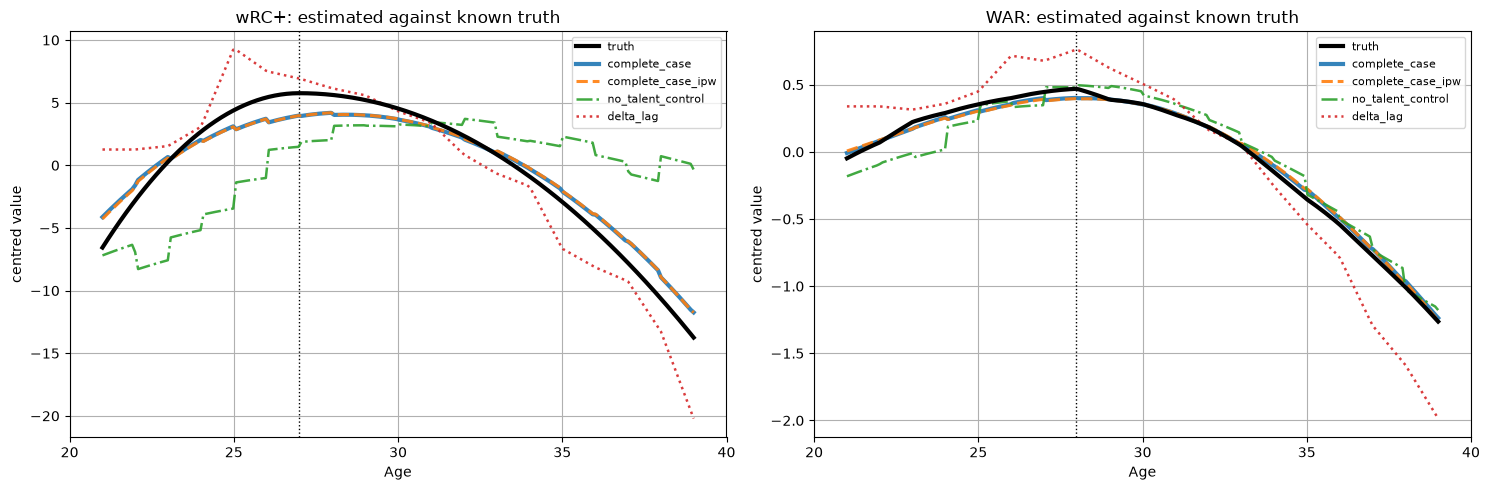

In [8]:
generated = simulate_careers(CONFIG, seed=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric_name in zip(axes, ["wRC+", "WAR"]):
    metric = CONFIG.metric(metric_name)
    truth = truth_curve(generated, metric)
    curves = {}
    for arm in ARMS:
        arm_ages, arm_values, _, _ = fit_arm(generated, metric, arm)
        curves[arm] = (arm_ages, arm_values)
    plot_curves_against_truth(
        curves, truth.ages, truth.values, f"{metric_name}: estimated against known truth", ax=ax
    )

fig.tight_layout()
plt.show()

## 6. Is Def's peak findable?

`CLAUDE.md` says Def's peak "is not measurable at this sample size — a resolution problem no change
of specification addresses". That was inferred from the peak scattering 21.0–25.0 under resampling.
Inferred, because the true peak is unknown.

Here it is assigned. And the right question is a surface rather than a number — a tall peak is
findable where a shallow one is not — so both the peak's **age** and its **height** are swept.
`rise_scale = 1.0` is the height Def's real fitted curve suggests.

In [9]:
sweep = peak_recovery_sweep("Def", n_sims=10)
peak_recovery_summary(sweep).round(3)

,assigned_peak,rise_scale,rise,bias,scatter,hit_rate
0,22.0,0.5,0.003,0.429,1.135,0.7
1,22.0,1.0,0.006,0.106,0.972,0.9
2,22.0,2.0,0.012,0.222,1.258,0.9
3,22.0,4.0,0.024,0.222,1.258,0.9
4,24.0,0.5,0.003,1.647,1.305,0.2
5,24.0,1.0,0.006,1.254,1.442,0.3
6,24.0,2.0,0.012,0.363,2.072,0.2
7,24.0,4.0,0.024,0.278,2.128,0.2
8,26.0,0.5,0.003,0.954,0.961,0.5
9,26.0,1.0,0.006,0.988,0.961,0.5


**Def's peak is recoverable only if it is early, and adding signal does not help.**

Hit rate is the share of replicates landing within one year of the truth:

| assigned peak | bias | scatter | hit rate |
|---|---|---|---|
| 22 | +0.11 to +0.43 | 0.97–1.26 | **0.7–0.9** |
| 24 | +0.28 to +1.65 | 1.31–2.13 | **0.2–0.3** |
| 26 | +0.95 to +1.38 | 0.75–0.99 | **0.4–0.5** |

Two things follow.

First, **making the peak eight times taller does not rescue it.** Across `rise_scale` 0.5 → 4.0 the
hit rate is flat at every assigned age — 0.2–0.3 at peak 24, 0.4–0.5 at peak 26. If this were purely
a signal-to-noise problem, a peak eight times more prominent would be far easier to find. It is not.

Second, the failure is **bias plus scatter, not scatter alone.** At an assigned peak of 24 the
estimator is off by up to +1.65 years on average, with scatter above two years.

So `CLAUDE.md`'s advice stands — keep saying "defense declines from the start of a major-league
career" — but its stated reason is incomplete. This is not only "a resolution problem at this sample
size". A systematic component is present that more data would not remove, and it is the same
specification bias section 4 isolates. The one case that *is* recovered reliably is a peak at 22,
which happens to be roughly where Def's real fitted curve puts it.

## 7. What this settles

Ordered by how much the evidence supports them.

1. **The GAM is a substantially better curve estimator than the delta method.** 9–10 replicates out
   of 10 on four of five metrics, mean SBD 1.6–2.5× lower. The project has always claimed this on
   per-season MAE, which `diagnostics.py` says cannot rank aging curves; here it holds on the
   literature's own shape score. Spd is the exception.

2. **The career-mean control is doing most of the work.** Dropping `s(1)` destroys the curve's shape
   (wRC+ SBD 0.022 → 0.469), losing 10/10 replicates. It is not free — section 2 shows it adds
   about +0.8 years of peak bias even when noiseless — but it removes far more than it adds.

3. **This vindicates a caveat in `CLAUDE.md` that had no evidence.** The docs defend Def's negative
   MAE result by asserting that "individual-season MAE and population curve *shape* are different
   targets; the defensive curve can still be the better shape estimate". Measured: on Def the GAM
   loses to `delta_lag` on per-season MAE by 6.3% and beats it on curve shape in 9/10 replicates.
   Both are true at once, exactly as the note claimed.

4. **IPW is not evaluated here.** The generator produces weights far too uniform (SD 0.18 against
   the real 0.43), and moves the simulated curve three to seven times less than IPW moves the real
   one. The arm is reported but under-powered by construction, and no conclusion about the
   correction should be drawn from this notebook in either direction.

5. **The published specification reads the peak late, and that is not survivorship.** Switching off
   both the qualification cut and selective survival leaves the bias intact (section 4), matching
   the clean-panel result in section 2. The cause is the career mean as a post-treatment control.

6. **Def's peak is unrecoverable unless it is early**, and making the peak eight times more
   prominent does not help — so it is not simply a sample-size problem, as the docs currently say.

## Honest limits

- **Everything here is computed on simulated data**, against a curve written down in `simulate.py`.
  Calibration (section 1) matches the real sample on 17 moments, which rules out obviously
  unrealistic generators — it does not make the conclusions facts about baseball.
- **Relative comparisons travel; absolute numbers do not.** Both arms of any comparison see
  identical simulated data, so a flaw in the generator hits them equally. "The GAM beats the delta
  method on shape" is far sturdier than any specific bias figure, and **no peak-bias number here
  should be quoted about real players.**
- The true curve is an asymmetric quadratic with a well-defined maximum, which raised the worry
  that it might be sharper than real aging and so flatter the peak results. **Section 1 measures
  that and largely clears it.** The flat band within 1% of the maximum is 1.81 years on the real
  wRC+ curve against 1.90 simulated, and 1.77 against 1.90 on OPS — matched, with the simulation
  marginally *flatter*. On Def and Spd the real curve is sharper than the simulated one, the
  opposite of the concern. The exception is **WAR**, real 2.26 years against 1.90... against a
  simulated 0.99, so roughly 2.3x flatter than the truth it was given; `GAM.ipynb` calls it "a broad
  plateau — 1.707 at 26 and 1.702 at 27", and its values run within 2.5% across ages 25-28. So the
  caveat applies to WAR's peak figure and not to wRC+'s or OPS's.
- Each metric carries one latent talent component, constant over a career, so simulated WAR is
  composite only through the talent covariance rather than as a sum of its parts.
- **The survival model is the generator's weakest part**, and it is the reason IPW cannot be
  assessed. Fixing it needs survival to depend on recent performance in a way the retirement model
  can learn. One attempt at that raised the weight spread from 0.18 to 0.28 while making the
  *curve-displacement* mismatch worse on two metrics, with every coefficient pinned at its bound —
  so the constraint looks like the survival model's single-population form, not its tuning. The
  right calibration target is IPW's curve displacement itself (11.2% on wRC+), which is directly
  measurable on real data; `sd(ipw_weight)` was used as a proxy and does not track it.